In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [2]:
os.makedirs("outputs", exist_ok=True)

In [3]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


# PyTorch Tensors
## Tensor Question 1 

In [4]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

In [5]:
for t in (a, b, c):
    print(t)
    print(t.shape)
    print(t.dtype)
    print(t.device)

# CPU and GPU both have their own memory. 
# For training, model and tensors/weight need to be on the same device.

tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
torch.float32
cpu
tensor([[0., 0., 0.],
        [0., 0., 0.]])
torch.Size([2, 3])
torch.float32
cpu
tensor([1., 1., 1., 1.])
torch.Size([4])
torch.float32
cpu


## Tensor Question 2

In [6]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

In [7]:
x_sqrt = x**0.5
print(x_sqrt)
x_sum = x.sum()
print(x_sum)
x_mean = x.mean()
print(x_mean)
max_value = x.argmax()
print(max_value)

# argmax returns the index with the max value, meaning it will 
# return the class that has the highest prediction score.

tensor([1., 2., 3., 4., 5.])
tensor(55.)
tensor(11.)
tensor(4)


## Tensor Question 3

In [8]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# Numpy arrays live on CPU only. Numpy doesn't have access to anything that's on GPU

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


## Tensor Question 4

In [9]:
t = torch.arange(24).float()

In [10]:
t1 = t.reshape(4, 6)
print(t1.shape)
t2 = t.reshape(2, 3, 4)
print(t2.shape)

torch.Size([4, 6])
torch.Size([2, 3, 4])


In [11]:
t3 = t1.unsqueeze(0)
print(t3.shape)

torch.Size([1, 4, 6])


Unsqueeze adds a batch size dimension to the shape. Otherwise there will be a shape mismatch.

## Tensor Question 5

In [12]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

In [13]:
np_prod = np.matmul(np_a, np_b)
print(np_prod)
t_prod = torch.matmul(t_a, t_b)
print(t_prod)

[[19. 22.]
 [43. 50.]]
tensor([[19., 22.],
        [43., 50.]])


In [14]:
print(np.allclose(np_prod, t_prod.numpy()))

True


As data passes through a layer, matrix multiplication is used to multiply input by weights.

# Pretrained Models
## Model Question 1

In [15]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Total parameters:     11,689,512
Trainable parameters: 11,689,512


Using pretrained weights allows to skip training part and save time and resources.

## Model Question 2

In [16]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

1. fc — fully connected layer. Output size 1000.
2. Deep network uses multiple layers.

## Model Question 3

In [17]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

Model ready for inference.


1. .to(device) moves the model to GPU because it needs access to GPU memory.
2. model.eval() starts evaluation mode. It turns off dropout so all neurons are active. Eval mode is requred for inference.

## Model Question 4

In [18]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


1. resize/crop makes all images the same size
2. ToTensor() transforms pixel values range to 0-1 range
3. The model expects inputs that look like what it was trained on

# Running Inference

In [19]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

In [20]:
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## Inference Question 1

In [21]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))
    with torch.no_grad():
        output = model(input_tensor)

    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
    probs = torch.nn.functional.softmax(output[0], dim=0)

    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    top5 = torch.topk(probs, 5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    return [(class_labels[top5.indices[i].item()], top5.values[i].item()) for i in range(5)]

In [22]:
img, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


All of the predictions map to a mountain scene. Except that I had to goolge promontory.

## Inference Question 2

In [23]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


The model is confident on mountain, because it closely matches ImageNet categories - alp, ski. Street images are the furthest from those categories.

## Inference Question 3

In [24]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


1. It's more precise than using numbers in range 0 to 1.
2. Probabilities for production filtering, because they're human-readable and you can set a threshold like "only keep predictions above 0.8."

## Inference Question 4

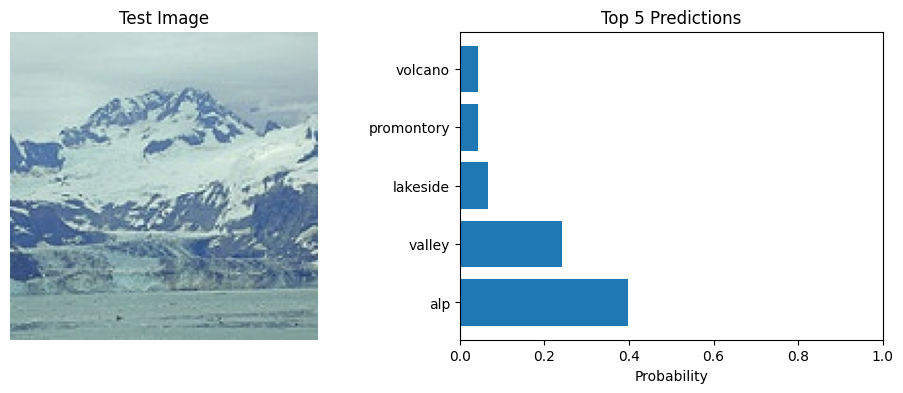

In [43]:
img, img_name = load_sample_image(LABELS[2])
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img)
ax1.axis('off')
ax1.set_title('Test Image')
names = [p[0] for p in preds]
probs = [p[1] for p in preds]
ax2.barh(names, probs)
ax2.set_title('Top 5 Predictions')
ax2.set_xlabel('Probability')
ax2.set_xlim(0,1)
plt.savefig('outputs/warmup_inference_viz.png', dpi=150, bbox_inches='tight')
plt.show()

1. For a non-technical reviewer I'd add a label "Model prediction: alp (39% confident)".
2. I'd use the probability threshold of at least 35%, because below that the model is making unreliable predictions.